In [1]:
print('aa')

aa


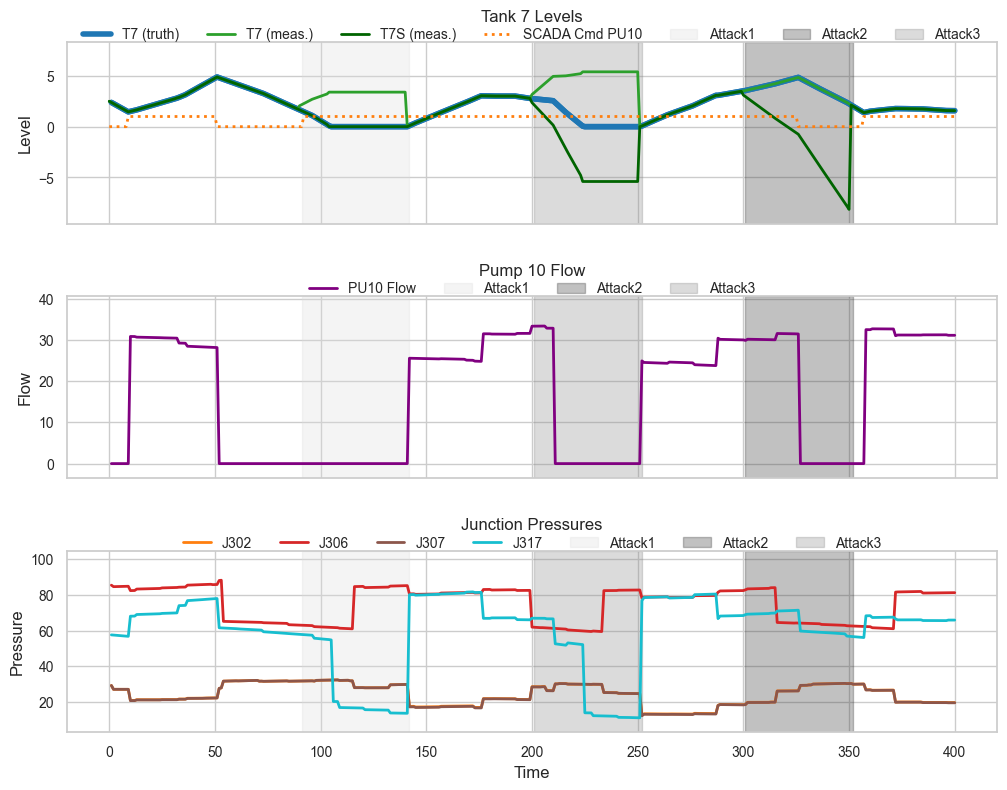

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import OrderedDict

# 1) Load data
gt_df  = pd.read_csv('../examples/ctown_topology/CtownTestingTwoAttacks/ground_truth.csv').drop(0)
plc_df = pd.read_csv('../examples/ctown_topology/CtownTestingTwoAttacks/PLC5_values.csv')

# 2) Find attack intervals
def find_intervals(df, col):
    ivals, start = [], None
    for idx, flag in enumerate(df[col]):
        t = df['iteration'].iat[idx]
        if flag == 1 and start is None:
            start = t
        elif flag == 0 and start is not None:
            ivals.append((start, t))
            start = None
    if start is not None:
        ivals.append((start, df['iteration'].iat[-1]))
    return ivals

attacks = {
    "Attack1": find_intervals(gt_df, 'plc9attack'),
    "Attack2": find_intervals(gt_df, 'plc9attack2'),
    "Attack3": find_intervals(gt_df, 'plc9attack3')
}

# 3) Style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 10),
    'axes.titlesize': 12,
    'axes.titlepad': 15,      # extra padding to push titles upward
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'lines.linewidth': 2
})

# 4) Define colors
t7_truth_col  = 'tab:blue'     # ground truth → blue
t7_meas_col   = 'tab:green'    # T7 measured → green
t7s_meas_col  = 'darkgreen'    # T7S measured → dark green
flow_col      = 'purple'       # PU10 flow → purple

junction_cols = {
    'J302': '#FF7F0E',  # orange
    'J306': '#D62728',  # red
    'J307': '#8C564B',  # brown
    'J317': '#17BECF',  # cyan
}

attack_cols = {
    'Attack1': '#DDDDDD',  # very light gray
    'Attack2': '#333333',  # medium gray
    'Attack3': '#888888',  # dark gray
}


# 5) Build the three panels
fig, axes = plt.subplots(3, 1, sharex=True)

# — Panel 1: Tank 7 Levels —
ax = axes[0]
ax.plot(
    gt_df.iteration,
    gt_df.T7_LEVEL,
    label='T7 (truth)',
    color=t7_truth_col,
    linewidth=4            # thicker truth line
)
ax.plot(gt_df.iteration, gt_df.T7_LEVEL,
        label='T7 (truth)', color=t7_truth_col, linewidth=4)
ax.plot(plc_df.iteration, plc_df.T7,
        label='T7 (meas.)', color=t7_meas_col)
ax.plot(plc_df.iteration, plc_df.T7S,
        label='T7S (meas.)', color=t7s_meas_col)
ax.plot(plc_df.iteration, plc_df.ScadaCommand_PU10,
        label='SCADA Cmd PU10', color='tab:orange', linestyle=':')
ax.set_title("Tank 7 Levels")
ax.set_ylabel("Level")

# — Panel 2: Pump 10 Flow —
ax = axes[1]
ax.plot(gt_df.iteration, gt_df.PU10_FLOW,
        label='PU10 Flow', color=flow_col)
ax.set_title("Pump 10 Flow")
ax.set_ylabel("Flow")

# — Panel 3: Junction Pressures —
ax = axes[2]
for name in ['J302_LEVEL','J306_LEVEL','J307_LEVEL','J317_LEVEL']:
    label = name.split('_')[0]
    ax.plot(gt_df.iteration, gt_df[name],
            label=label,
            color=junction_cols[label])
ax.set_title("Junction Pressures")
ax.set_ylabel("Pressure")
ax.set_xlabel("Time")

# 6) Shade attack windows
for atk, ivals in attacks.items():
    for start, end in ivals:
        for ax in axes:
            ax.axvspan(start, end,
                       color=attack_cols[atk],
                       alpha=0.3,
                       label=atk if start == ivals[0][0] else "")

# 7) Pad y-limits & place legend top-center
for ax in axes:
    y0, y1 = ax.get_ylim()
    dy = y1 - y0
    ax.set_ylim(y0 - 0.05*dy, y1 + 0.15*dy)

    handles, labels = ax.get_legend_handles_labels()
    uniq = OrderedDict(zip(labels, handles))
    ax.legend(uniq.values(), uniq.keys(),
              loc='upper center',
              bbox_to_anchor=(0.5, 1.15),
              ncol=8,
              frameon=False)

# 8) Final layout, save & show
plt.subplots_adjust(
    top=0.80,   # more room at the top for the first title
    hspace=0.4
)
outdir = 'output/HybridCtownCase3'
os.makedirs(outdir, exist_ok=True)
plt.savefig(f'{outdir}/PLC5.png', dpi=300)
plt.show()


# Visuzalize with guarrail the groundtruth
